<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day11-discussion-2.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 11, Part 2 discussion — Does a protein language model know about structure?

ESM-2 was trained only to fill in masked residues. Rao et al. (2021)
showed that the attention maps of such models nevertheless predict which
residues are in contact in 3D. `fair-esm` includes that predictor: a
logistic regression over the attention maps, fitted once by the ESM
authors.

Here: predict β-globin's contacts from its sequence alone with ESM-2
models of increasing size, and compare them with the real contact map
from PDB 4HHB (Day 10). Score: the fraction of the top L/5 predicted
long-range pairs (|i − j| ≥ 24) that really are in contact.

**Predict first:** will a bigger model know more about structure, or is
contact information there from the start? (On Colab: `!pip install fair-esm`.)

In [1]:
import io, requests, numpy as np, torch, esm
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_index, index_to_one

text = requests.get("https://files.rcsb.org/download/4HHB.pdb", timeout=60).text
chain = PDBParser(QUIET=True).get_structure("4HHB", io.StringIO(text))[0]["B"]
residues = [r for r in chain if r.id[0] == " "]
seq = "".join(index_to_one(three_to_index(r.get_resname())) for r in residues)
xyz = np.array([(r["CB"] if "CB" in r else r["CA"]).coord for r in residues])
true_contacts = np.linalg.norm(xyz[:, None] - xyz[None], axis=2) < 8.0
L = len(seq)
i, j = np.triu_indices(L, 24)
print(f"β-globin, {L} residues; {true_contacts[i, j].sum()} true long-range contacts; "
      f"a random guess would be right {true_contacts[i, j].mean():.3f} of the time")

β-globin, 146 residues; 150 true long-range contacts; a random guess would be right 0.020 of the time


In [2]:
RUN_650M = False    # the 650M model is a ~2.5 GB download; set True if you have the time and memory
names = ["esm2_t6_8M_UR50D", "esm2_t12_35M_UR50D", "esm2_t30_150M_UR50D"] + (["esm2_t33_650M_UR50D"] if RUN_650M else [])
predicted = {}
for name in names:
    model, alphabet = getattr(esm.pretrained, name)()
    model.eval()
    _, _, tokens = alphabet.get_batch_converter()([("hbb", seq)])
    with torch.no_grad():
        P = model(tokens, return_contacts=True)["contacts"][0].numpy()
    top = np.argsort(-P[i, j])[: L // 5]
    n_params = sum(p.numel() for p in model.parameters())
    predicted[name] = P
    print(f"{name:22s} {n_params / 1e6:6.0f}M parameters: top-L/5 long-range precision {true_contacts[i[top], j[top]].mean():.3f}")
    del model

esm2_t6_8M_UR50D            8M parameters: top-L/5 long-range precision 0.000


esm2_t12_35M_UR50D         34M parameters: top-L/5 long-range precision 0.172


esm2_t30_150M_UR50D       148M parameters: top-L/5 long-range precision 0.621


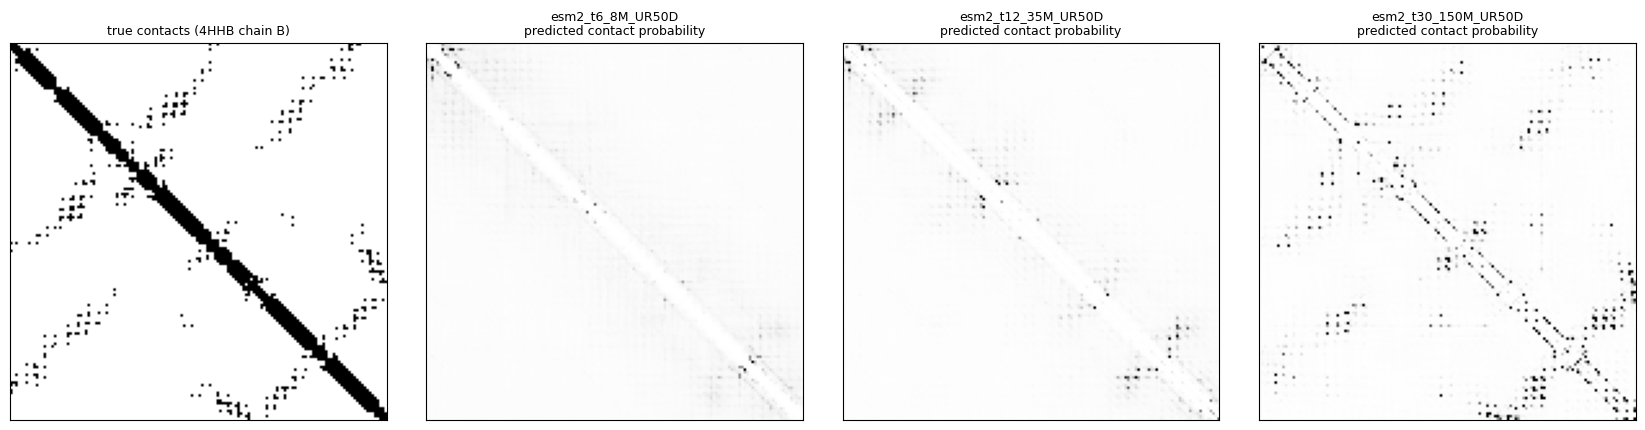

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(predicted) + 1, figsize=(4.2 * (len(predicted) + 1), 4.2))
axes[0].imshow(true_contacts, cmap="Greys"); axes[0].set_title("true contacts (4HHB chain B)", fontsize=9)
for ax, (name, P) in zip(axes[1:], predicted.items()):
    ax.imshow(P, cmap="Greys", vmin=0, vmax=0.5); ax.set_title(f"{name}\npredicted contact probability", fontsize=9)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

For reference: run on this course's machine, the 650M-parameter
`esm2_t33_650M_UR50D` reached a top-L/5 long-range precision of 0.897 on
the same protein.

**Discuss:**

1. How does the contact precision change with model size? Is structural
   knowledge present in the smallest model at all?
2. None of these models was ever shown a structure. Where does the contact
   information come from? (Hint: Day 10's coevolution, and what a model
   must learn to fill in a masked residue well.)
3. The largest ESM-2 models are used by ESMFold to predict full 3D
   structures from a single sequence. What would you expect for a protein
   from a small family with few homologs in the training data?